# Sentinel-2 Collection-1 L2A retrieval for the NCA

Configured for MGRS tiles **11TNJ, 11TNH, and 11TPH**.

- AOI: `A:\NCA_DATA\templates\NCA_NAD83UTM11N.shp`
- Output: `A:\NCA_DATA\S2_2016-2017`

The notebook authenticates to CDSE, inventories all 2016–2017 L2A products, reports exact catalogue volume, downloads SAFE products, extracts BOA bands and SCL, clips to the buffered NCA extent, and writes upload-ready multiband GeoTIFFs.


## 1. Install dependencies

In [1]:
pip install requests pandas geopandas rasterio tqdm pyarrow

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [2]:
from __future__ import annotations
import getpass, json, re, shutil, time, zipfile
from datetime import datetime, timezone
from pathlib import Path
from typing import Iterable

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import requests
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from rasterio.windows import Window, from_bounds
from tqdm.auto import tqdm


## 3. Settings

In [3]:
MGRS_TILES = ["11TNJ", "11TNH", "11TPH"]

START_DATE = "2016-01-01T00:00:00.000Z"
END_DATE_EXCLUSIVE = "2018-01-01T00:00:00.000Z"

AOI_PATH = Path(r"A:\NCA_DATA\templates\NCA_NAD83UTM11N.shp")
AOI_BUFFER_METERS = 500

ROOT = Path(r"A:\NCA_DATA\S2_2016-2017")
ZIP_DIR = ROOT / "safe_zip"
SAFE_DIR = ROOT / "safe_extracted"
TIF_DIR = ROOT / "gee_ready"
MANIFEST_DIR = ROOT / "manifests"

KEEP_SAFE_ZIPS = True
KEEP_EXTRACTED_SAFE = False

REFLECTANCE_BANDS = ["B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12"]
OUTPUT_BANDS = REFLECTANCE_BANDS + ["SCL"]

for d in [ROOT, ZIP_DIR, SAFE_DIR, TIF_DIR, MANIFEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("AOI:", AOI_PATH)
print("Output:", ROOT)
print("Tiles:", MGRS_TILES)


AOI: A:\NCA_DATA\templates\NCA_NAD83UTM11N.shp
Output: A:\NCA_DATA\S2_2016-2017
Tiles: ['11TNJ', '11TNH', '11TPH']


## 4. Load and validate AOI

In [4]:
if not AOI_PATH.exists():
    raise FileNotFoundError(f"AOI not found: {AOI_PATH}")

aoi = gpd.read_file(AOI_PATH)
if aoi.empty:
    raise ValueError("AOI shapefile contains no features.")
if aoi.crs is None:
    raise ValueError("AOI shapefile has no CRS.")

aoi = aoi[aoi.geometry.notna()].copy()
aoi["geometry"] = aoi.geometry.make_valid()

print("CRS:", aoi.crs)
print("Features:", len(aoi))
print("Area:", f"{aoi.to_crs(26911).geometry.area.sum()/1e6:,.1f} km²")
if aoi.crs.to_epsg() != 26911:
    print("WARNING: AOI is not formally tagged EPSG:26911.")


CRS: EPSG:26911
Features: 1
Area: 4,454.1 km²


## 5. CDSE credentials

Create an account at https://dataspace.copernicus.eu/

Run the next cell and enter your CDSE username/email and password. The password is hidden and not saved in notebook output.


In [34]:
CDSE_USERNAME = input("CDSE username or email: ")
CDSE_PASSWORD = getpass.getpass("CDSE password: ")


## 6. Authentication

In [35]:
TOKEN_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
CATALOGUE_URL = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
DOWNLOAD_ROOT = "https://download.dataspace.copernicus.eu/odata/v1/Products"

def request_cdse_token(username, password):
    r = requests.post(TOKEN_URL, data={
        "client_id": "cdse-public",
        "grant_type": "password",
        "username": username,
        "password": password,
    }, timeout=60)
    if not r.ok:
        raise RuntimeError(f"Authentication failed: {r.status_code}\n{r.text[:1000]}")
    p = r.json()
    return {
        "access_token": p["access_token"],
        "refresh_token": p.get("refresh_token"),
        "expires_at": time.time() + int(p.get("expires_in", 600)) - 60,
    }

def refresh_cdse_token(token):
    r = requests.post(TOKEN_URL, data={
        "client_id": "cdse-public",
        "grant_type": "refresh_token",
        "refresh_token": token["refresh_token"],
    }, timeout=60)
    r.raise_for_status()
    p = r.json()
    return {
        "access_token": p["access_token"],
        "refresh_token": p.get("refresh_token", token["refresh_token"]),
        "expires_at": time.time() + int(p.get("expires_in", 600)) - 60,
    }

token = request_cdse_token(CDSE_USERNAME, CDSE_PASSWORD)
print("Authentication succeeded.")


Authentication succeeded.


## 7. Product parsing and query functions

In [7]:
def parse_mgrs_tile(name):
    m = re.search(r"_T([0-9]{2}[A-Z]{3})_", name)
    if not m: raise ValueError(name)
    return m.group(1)

def parse_sensing_time(name):
    m = re.search(r"MSIL2A_(\d{8}T\d{6})_", name)
    if not m: raise ValueError(name)
    return pd.Timestamp(datetime.strptime(m.group(1), "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc))

def parse_processing_baseline(name):
    m = re.search(r"_(N\d{4})_", name)
    return m.group(1) if m else "UNKNOWN"

def baseline_number(value):
    m = re.fullmatch(r"N(\d{4})", str(value))
    return int(m.group(1)) if m else -1

def build_odata_filter(tile):
    return " and ".join([
        "Collection/Name eq 'SENTINEL-2'",
        "contains(Name,'MSIL2A')",
        f"contains(Name,'_T{tile}_')",
        f"ContentDate/Start ge {START_DATE}",
        f"ContentDate/Start lt {END_DATE_EXCLUSIVE}",
        "Online eq true",
    ])

def query_cdse_tile(tile):
    params = {
        "$filter": build_odata_filter(tile),
        "$select": "Id,Name,S3Path,ContentDate,PublicationDate,ModificationDate,ContentLength,Online",
        "$orderby": "ContentDate/Start asc",
        "$top": "1000",
    }
    records, url, first = [], CATALOGUE_URL, True
    while url:
        r = requests.get(url, params=params if first else None, timeout=120)
        if not r.ok:
            raise RuntimeError(f"Query failed for {tile}: {r.status_code}\\n{r.text[:2000]}")
        p = r.json()
        records.extend(p.get("value", []))
        url = p.get("@odata.nextLink")
        first = False
    return records


## 8. Query all tiles

In [8]:
records = []
for tile in MGRS_TILES:
    print("Querying", tile)
    rows = query_cdse_tile(tile)
    print(" returned", len(rows))
    records.extend(rows)

products_raw = pd.DataFrame(records)
if products_raw.empty:
    raise RuntimeError("No products returned.")
display(products_raw.head())


Querying 11TNJ
 returned 182
Querying 11TNH
 returned 180
Querying 11TPH
 returned 216


,@odata.mediaContentType,Id,Name,ContentLength,PublicationDate,ModificationDate,Online,S3Path,ContentDate
0,application/octet-stream,96ad3fb9-ec0d-4010-9b0a-dd0442ae3121,S2A_MSIL2A_20160103T185122_N0500_R070_T11TNJ_2...,827504766,2024-06-10T04:53:22.691259Z,2025-07-05T19:42:42.253174Z,True,/eodata/Sentinel-2/MSI/L2A_N0500/2016/01/03/S2...,"{'Start': '2016-01-03T18:51:22.030000Z', 'End'..."
1,application/octet-stream,c738c922-17e1-40d7-8625-7a2b3c0e4e2e,S2A_MSIL2A_20160110T184122_N0500_R027_T11TNJ_2...,1010543090,2024-05-23T05:07:15.815088Z,2025-07-05T19:12:20.748610Z,True,/eodata/Sentinel-2/MSI/L2A_N0500/2016/01/10/S2...,"{'Start': '2016-01-10T18:41:22.030000Z', 'End'..."
2,application/octet-stream,7f661507-d63c-4220-8f9f-72bae44cde14,S2A_MSIL2A_20160113T184732_N0500_R070_T11TNJ_2...,764510469,2024-06-01T05:52:13.811356Z,2025-07-05T19:00:17.829511Z,True,/eodata/Sentinel-2/MSI/L2A_N0500/2016/01/13/S2...,"{'Start': '2016-01-13T18:47:32.030000Z', 'End'..."
3,application/octet-stream,fe12c86d-2410-4d1a-b834-6917a08b5341,S2A_MSIL2A_20160120T184112_N0500_R027_T11TNJ_2...,812344464,2024-05-22T17:39:26.052047Z,2025-07-05T18:31:31.688083Z,True,/eodata/Sentinel-2/MSI/L2A_N0500/2016/01/20/S2...,"{'Start': '2016-01-20T18:41:12.030000Z', 'End'..."
4,application/octet-stream,5d1b91e8-fb7c-48db-950c-18df7fde02c0,S2A_MSIL2A_20160123T185112_N0500_R070_T11TNJ_2...,789829776,2024-05-23T02:29:42.267465Z,2025-07-05T18:18:41.647119Z,True,/eodata/Sentinel-2/MSI/L2A_N0500/2016/01/23/S2...,"{'Start': '2016-01-23T18:51:12.029000Z', 'End'..."


## 9. Deduplicate and inventory

In [9]:
products = products_raw.copy()
products["mgrs_tile"] = products["Name"].map(parse_mgrs_tile)
products["sensing_time"] = products["Name"].map(parse_sensing_time)
products["processing_baseline"] = products["Name"].map(parse_processing_baseline)
products["satellite"] = products["Name"].str[:3]
products["publication_time"] = pd.to_datetime(products["PublicationDate"], utc=True, errors="coerce")
products["content_bytes"] = pd.to_numeric(products["ContentLength"], errors="coerce")
products["baseline_number"] = products["processing_baseline"].map(baseline_number)

products = (
    products.sort_values(["satellite","sensing_time","mgrs_tile","baseline_number","publication_time"])
    .drop_duplicates(["satellite","sensing_time","mgrs_tile"], keep="last")
    .sort_values(["sensing_time","mgrs_tile","satellite"])
    .reset_index(drop=True)
)

print("Selected tile-products:", len(products))
display(products[["sensing_time","satellite","mgrs_tile","processing_baseline","content_bytes","Name"]].head(20))


Selected tile-products: 562


,sensing_time,satellite,mgrs_tile,processing_baseline,content_bytes,Name
0,2016-01-03 18:51:22+00:00,S2A,11TNH,N0500,854475864,S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_2...
1,2016-01-03 18:51:22+00:00,S2A,11TNJ,N0500,827504766,S2A_MSIL2A_20160103T185122_N0500_R070_T11TNJ_2...
2,2016-01-03 18:51:22+00:00,S2A,11TPH,N0500,39069351,S2A_MSIL2A_20160103T185122_N0500_R070_T11TPH_2...
3,2016-01-10 18:41:22+00:00,S2A,11TNH,N0500,1124425529,S2A_MSIL2A_20160110T184122_N0500_R027_T11TNH_2...
4,2016-01-10 18:41:22+00:00,S2A,11TNJ,N0500,1010543090,S2A_MSIL2A_20160110T184122_N0500_R027_T11TNJ_2...
5,2016-01-10 18:41:22+00:00,S2A,11TPH,N0500,1061391133,S2A_MSIL2A_20160110T184122_N0500_R027_T11TPH_2...
6,2016-01-13 18:47:32+00:00,S2A,11TNH,N0500,712112586,S2A_MSIL2A_20160113T184732_N0500_R070_T11TNH_2...
7,2016-01-13 18:47:32+00:00,S2A,11TNJ,N0500,764510469,S2A_MSIL2A_20160113T184732_N0500_R070_T11TNJ_2...
8,2016-01-13 18:47:32+00:00,S2A,11TPH,N0500,48379411,S2A_MSIL2A_20160113T184732_N0500_R070_T11TPH_2...
9,2016-01-17 18:27:12+00:00,S2A,11TPH,N0500,40621430,S2A_MSIL2A_20160117T182712_N0500_R127_T11TPH_2...


## 10. Processing baseline summary

In [10]:
display(
    products.groupby(
        [products["sensing_time"].dt.year.rename("year"), "processing_baseline"]
    ).size().rename("n_products").reset_index()
)


,year,processing_baseline,n_products
0,2016,N0500,202
1,2017,N0500,360


## 11. Exact CDSE archive volume

In [11]:
volume_summary = (
    products.assign(
        year=products["sensing_time"].dt.year,
        download_gib=products["content_bytes"]/(1024**3),
    )
    .groupby(["year","mgrs_tile"], dropna=False)
    .agg(products=("Name","size"), download_gib=("download_gib","sum"))
    .reset_index()
)
display(volume_summary)

total_gib = products["content_bytes"].sum()/(1024**3)
print(f"Reported CDSE download volume: {total_gib:,.1f} GiB")
print("Products lacking ContentLength:", products["content_bytes"].isna().sum())

products.to_csv(MANIFEST_DIR/"S2_C1_L2A_2016_2017_inventory.csv", index=False)
products.to_parquet(MANIFEST_DIR/"S2_C1_L2A_2016_2017_inventory.parquet", index=False)


,year,mgrs_tile,products,download_gib
0,2016,11TNH,63,58.225835
1,2016,11TNJ,63,57.126964
2,2016,11TPH,76,32.515027
3,2017,11TNH,112,102.931280
4,2017,11TNJ,112,97.826997
5,2017,11TPH,136,58.250520


Reported CDSE download volume: 406.9 GiB
Products lacking ContentLength: 0


## 12. Download function

In [12]:
def ensure_valid_token(token):
    return refresh_cdse_token(token) if time.time() >= token["expires_at"] else token

def download_product(row, token, chunk_size=8*1024*1024):
    token = ensure_valid_token(token)
    product_name = row["Name"].removesuffix(".SAFE")
    destination = ZIP_DIR/f"{product_name}.zip"
    partial = ZIP_DIR/f"{product_name}.zip.part"

    if destination.exists() and destination.stat().st_size > 0:
        return destination, token

    url = f"{DOWNLOAD_ROOT}({row['Id']})/$value"
    headers = {"Authorization": f"Bearer {token['access_token']}"}
    r = requests.get(url, headers=headers, stream=True, allow_redirects=True, timeout=(60,900))

    if r.status_code == 401:
        r.close()
        token = refresh_cdse_token(token)
        return download_product(row, token, chunk_size)

    r.raise_for_status()
    total = int(r.headers.get("content-length", row.get("content_bytes", 0) or 0))

    with r, open(partial, "wb") as dst, tqdm(
        total=total, unit="B", unit_scale=True, desc=product_name[:45], leave=False
    ) as progress:
        for chunk in r.iter_content(chunk_size=chunk_size):
            if chunk:
                dst.write(chunk)
                progress.update(len(chunk))

    partial.replace(destination)
    return destination, token


## 13. Test one product download

In [13]:
test_row = products.iloc[0]
test_zip, token = download_product(test_row, token)
print(test_zip)
print(f"Size: {test_zip.stat().st_size/(1024**3):.2f} GiB")


S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_:   0%|          | 0.00/854M [00:00<?, ?B/s]

A:\NCA_DATA\S2_2016-2017\safe_zip\S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_20231014T014631.zip
Size: 0.80 GiB


## 14. SAFE extraction and band discovery

In [14]:
def extract_safe(zip_path):
    expected = SAFE_DIR/f"{zip_path.stem}.SAFE"
    if expected.exists():
        return expected
    with zipfile.ZipFile(zip_path) as z:
        roots = {Path(m).parts[0] for m in z.namelist() if m and Path(m).parts}
        z.extractall(SAFE_DIR)
    candidates = [SAFE_DIR/r for r in roots if r.endswith(".SAFE")]
    if len(candidates) != 1:
        raise RuntimeError(f"Expected one SAFE root; found {candidates}")
    return candidates[0]

def first_match(root, patterns):
    matches = []
    for pattern in patterns:
        matches.extend(root.glob(pattern))
    matches = sorted(set(matches))
    if not matches:
        raise FileNotFoundError(f"No match for {patterns} under {root}")
    return matches[0]

def locate_l2a_bands(safe_dir):
    return {
        "B2": first_match(safe_dir, ["**/R10m/*_B02_10m.jp2"]),
        "B3": first_match(safe_dir, ["**/R10m/*_B03_10m.jp2"]),
        "B4": first_match(safe_dir, ["**/R10m/*_B04_10m.jp2"]),
        "B8": first_match(safe_dir, ["**/R10m/*_B08_10m.jp2"]),
        "B5": first_match(safe_dir, ["**/R20m/*_B05_20m.jp2"]),
        "B6": first_match(safe_dir, ["**/R20m/*_B06_20m.jp2"]),
        "B7": first_match(safe_dir, ["**/R20m/*_B07_20m.jp2"]),
        "B8A": first_match(safe_dir, ["**/R20m/*_B8A_20m.jp2"]),
        "B11": first_match(safe_dir, ["**/R20m/*_B11_20m.jp2"]),
        "B12": first_match(safe_dir, ["**/R20m/*_B12_20m.jp2"]),
        "SCL": first_match(safe_dir, ["**/R20m/*_SCL_20m.jp2"]),
    }

test_safe = extract_safe(test_zip)
for b, p in locate_l2a_bands(test_safe).items():
    print(b, p.name)


B2 T11TNH_20160103T185122_B02_10m.jp2
B3 T11TNH_20160103T185122_B03_10m.jp2
B4 T11TNH_20160103T185122_B04_10m.jp2
B8 T11TNH_20160103T185122_B08_10m.jp2
B5 T11TNH_20160103T185122_B05_20m.jp2
B6 T11TNH_20160103T185122_B06_20m.jp2
B7 T11TNH_20160103T185122_B07_20m.jp2
B8A T11TNH_20160103T185122_B8A_20m.jp2
B11 T11TNH_20160103T185122_B11_20m.jp2
B12 T11TNH_20160103T185122_B12_20m.jp2
SCL T11TNH_20160103T185122_SCL_20m.jp2


## 15. AOI window and GeoTIFF preparation

In [20]:
def get_aoi_window(reference, aoi_gdf, buffer_meters):
    geometry = aoi_gdf.to_crs(reference.crs).geometry.union_all()
    if buffer_meters > 0:
        geometry = geometry.buffer(buffer_meters)

    left,bottom,right,top = geometry.bounds
    rl,rb,rr,rt = reference.bounds
    left,bottom,right,top = max(left,rl),max(bottom,rb),min(right,rr),min(top,rt)

    if left >= right or bottom >= top:
        raise ValueError("AOI does not overlap tile.")

    return from_bounds(left,bottom,right,top,transform=reference.transform).round_offsets().round_lengths()

def make_gee_ready_tif(row, safe_dir, aoi_gdf):
    product_id = row["Name"].removesuffix(".SAFE")
    output_tif = TIF_DIR/f"{product_id}_GEE.tif"
    output_json = TIF_DIR/f"{product_id}_GEE.json"

    if output_tif.exists() and output_json.exists():
        return output_tif, output_json

    paths = locate_l2a_bands(safe_dir)
    with rasterio.open(paths["B2"]) as ref:
        window = get_aoi_window(ref, aoi_gdf, AOI_BUFFER_METERS)
        transform = ref.window_transform(window)
        profile = ref.profile.copy()
        profile.update(
            driver="GTiff",
            width=int(window.width),
            height=int(window.height),
            transform=transform,
            count=len(OUTPUT_BANDS),
            dtype="uint16",
            nodata=0,
            tiled=True,
            blockxsize=512,
            blockysize=512,
            compress="ZSTD",
            predictor=2,
            interleave="band",
            BIGTIFF="IF_SAFER",
        )

        with rasterio.open(output_tif, "w", **profile) as dst:
            for i, band in enumerate(OUTPUT_BANDS, start=1):
                resampling = Resampling.nearest if band == "SCL" else Resampling.bilinear
                with rasterio.open(paths[band]) as src:
                    with WarpedVRT(
                        src, crs=ref.crs, transform=ref.transform,
                        width=ref.width, height=ref.height,
                        nodata=0, resampling=resampling
                    ) as vrt:
                        arr = vrt.read(1, window=window, out_dtype="uint16")
                dst.write(arr, i)
                dst.set_band_description(i, band)

            dst.update_tags(
                PRODUCT_ID=product_id,
                MGRS_TILE=row["mgrs_tile"],
                PROCESSING_BASELINE=row["processing_baseline"],
                SENSING_TIME=row["sensing_time"].isoformat(),
                SOURCE="CDSE_COLLECTION1_L2A",
            )

    metadata = {
        "product_id": product_id,
        "mgrs_tile": row["mgrs_tile"],
        "satellite": row["satellite"],
        "sensing_time": row["sensing_time"].isoformat(),
        "system_time_start_ms": int(row["sensing_time"].timestamp()*1000),
        "processing_baseline": row["processing_baseline"],
        "source": "CDSE_COLLECTION1_L2A",
        "bands": OUTPUT_BANDS,
        "aoi_buffer_meters": AOI_BUFFER_METERS,
    }
    output_json.write_text(json.dumps(metadata, indent=2))
    return output_tif, output_json


## 16. Test GeoTIFF preparation and estimate output volume

In [22]:
test_tif, test_json = make_gee_ready_tif(test_row, test_safe, aoi)
print(test_tif)
print(f"Prepared TIFF: {test_tif.stat().st_size/(1024**3):.3f} GiB")

with rasterio.open(test_tif) as src:
    print("Shape:", src.height, src.width)
    print("Bands:", src.count)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Descriptions:", src.descriptions)

estimated_gib = test_tif.stat().st_size * len(products)/(1024**3)
print(f"Simple total prepared-TIFF estimate: {estimated_gib:,.1f} GiB")


A:\NCA_DATA\S2_2016-2017\gee_ready\S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_20231014T014631_GEE.tif
Prepared TIFF: 0.466 GiB
Shape: 6366 8254
Bands: 11
CRS: EPSG:32611
Resolution: (10.0, 10.0)
Descriptions: ('B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'SCL')
Simple total prepared-TIFF estimate: 261.9 GiB


Raster: A:\NCA_DATA\S2_2016-2017\gee_ready\S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_20231014T014631_GEE.tif
CRS: EPSG:32611
Bounds: BoundingBox(left=527240.0, bottom=4736340.0, right=609780.0, top=4800000.0)
Band descriptions: ('B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'SCL')
Channel 1 stretch: 0.2462 to 1.2097
Channel 2 stretch: 0.2409 to 1.2107
Channel 3 stretch: 0.2316 to 1.2332


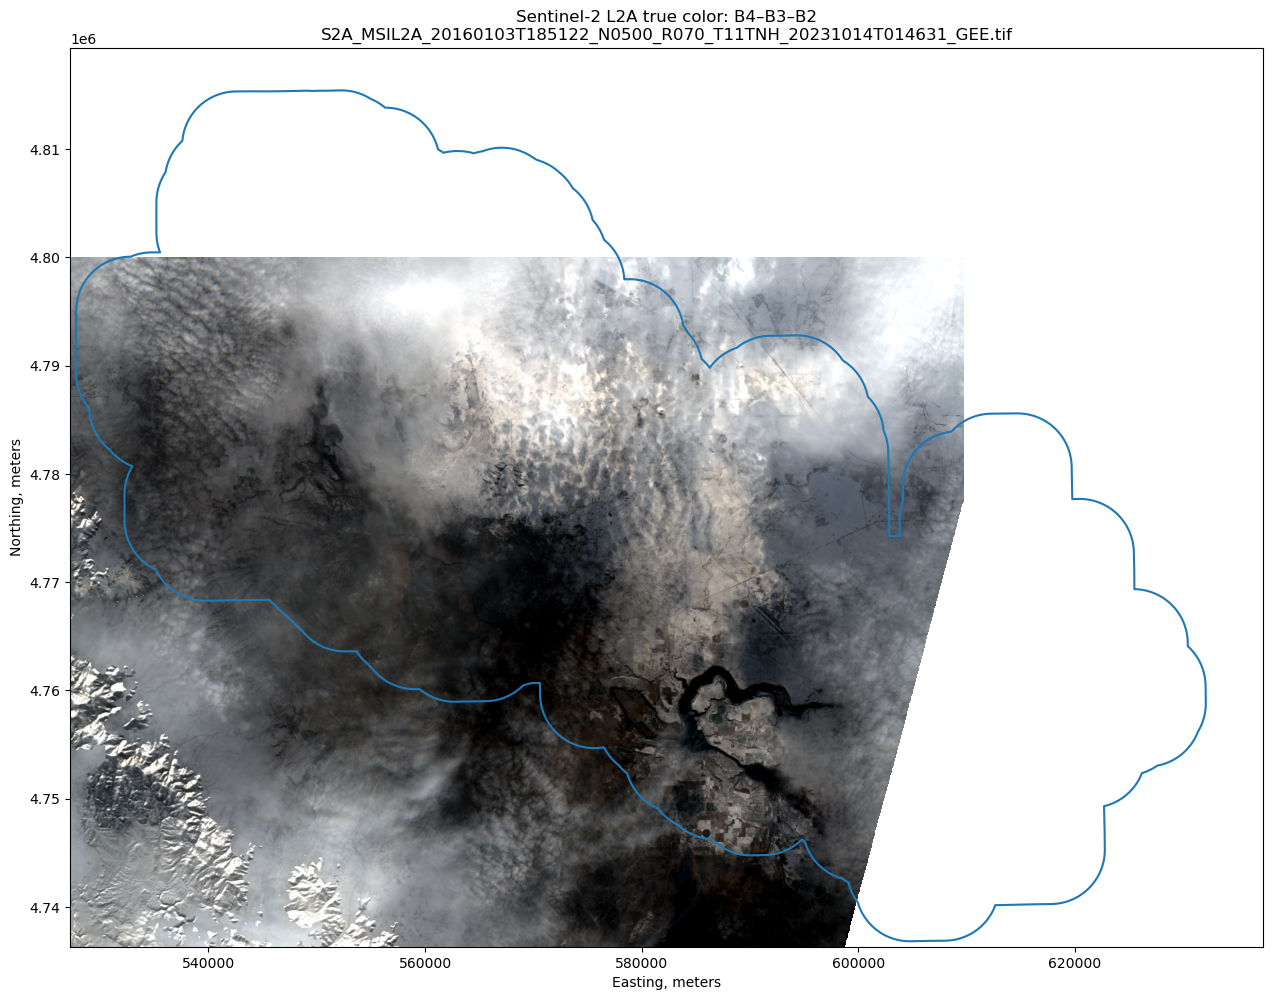

In [23]:
#visualize the test tif

import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import rasterio

from rasterio.enums import Resampling
from rasterio.plot import plotting_extent


# TIFF generated by the test step
rgb_tif = test_tif

# Reload AOI if necessary
aoi_plot = gpd.read_file(
    r"A:\NCA_DATA\templates\NCA_NAD83UTM11N.shp"
)

with rasterio.open(rgb_tif) as src:
    print("Raster:", rgb_tif)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Band descriptions:", src.descriptions)

    # Output dimensions for notebook visualization only.
    # This does not alter the source TIFF.
    display_max_dimension = 1800
    scale_factor = max(
        src.width / display_max_dimension,
        src.height / display_max_dimension,
        1,
    )

    display_width = max(
        1,
        int(src.width / scale_factor),
    )
    display_height = max(
        1,
        int(src.height / scale_factor),
    )

    # Bands in the TIFF:
    # 1=B2, 2=B3, 3=B4
    # Read as R,G,B = B4,B3,B2
    rgb = src.read(
        [3, 2, 1],
        out_shape=(
            3,
            display_height,
            display_width,
        ),
        resampling=Resampling.bilinear,
        masked=True,
    ).astype(np.float32)

    extent = plotting_extent(src)
    raster_crs = src.crs


# Convert scaled Sentinel-2 BOA DN to reflectance
rgb *= 0.0001

# A pixel is valid when it is not masked in all three bands
combined_mask = np.all(
    np.ma.getmaskarray(rgb),
    axis=0,
)

valid = ~combined_mask

if not np.any(valid):
    raise RuntimeError(
        "No valid RGB pixels were found in the TIFF."
    )


# Independent 2–98% stretch by channel
rgb_stretched = np.zeros(
    rgb.shape,
    dtype=np.float32,
)

for channel in range(3):
    channel_data = rgb[channel].filled(np.nan)
    values = channel_data[valid]
    values = values[np.isfinite(values)]

    low, high = np.percentile(
        values,
        [2, 98],
    )

    print(
        f"Channel {channel + 1} stretch:",
        f"{low:.4f} to {high:.4f}",
    )

    if high <= low:
        raise RuntimeError(
            f"Invalid stretch for RGB channel {channel + 1}."
        )

    rgb_stretched[channel] = np.clip(
        (channel_data - low) / (high - low),
        0,
        1,
    )


# Convert from bands × rows × columns to rows × columns × RGB
rgb_display = np.moveaxis(
    rgb_stretched,
    0,
    -1,
)

# Make nodata transparent
alpha = valid.astype(np.float32)

rgba_display = np.dstack(
    [rgb_display, alpha]
)


# Reproject AOI to raster CRS
aoi_plot = aoi_plot.to_crs(raster_crs)


fig, ax = plt.subplots(
    figsize=(13, 10),
)

ax.imshow(
    rgba_display,
    extent=extent,
    origin="upper",
)

aoi_plot.boundary.plot(
    ax=ax,
    linewidth=1.5,
)

ax.set_title(
    "Sentinel-2 L2A true color: B4–B3–B2\n"
    + rgb_tif.name
)

ax.set_xlabel("Easting, meters")
ax.set_ylabel("Northing, meters")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [24]:
with rasterio.open(test_tif) as src:
    print("Dtypes:", src.dtypes)
    print("Compression:", src.compression)
    print("Predictor:", src.profile.get("predictor"))
    print("Tiled:", src.is_tiled)
    print("Block shapes:", src.block_shapes)
    print("Nodata:", src.nodata)
    print("Driver:", src.driver)

    nominal_bytes = (
        src.width
        * src.height
        * src.count
        * np.dtype(src.dtypes[0]).itemsize
    )

    print(
        "Nominal uncompressed payload:",
        f"{nominal_bytes / 1024**3:.3f} GiB",
    )

print(
    "Actual file size:",
    f"{test_tif.stat().st_size / 1024**3:.3f} GiB",
)

Dtypes: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')
Compression: Compression.zstd
Predictor: None
Tiled: True
Block shapes: [(512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512)]
Nodata: 0.0
Driver: GTiff
Nominal uncompressed payload: 1.077 GiB
Actual file size: 0.466 GiB


In [25]:
with rasterio.open(test_tif) as src:
    print("Profile:")
    print(src.profile)

    print("\nIMAGE_STRUCTURE tags:")
    print(src.tags(ns="IMAGE_STRUCTURE"))

    print("\nDataset tags:")
    print(src.tags())

    print("\nSubdatasets:")
    print(src.subdatasets)

    print("\nOverview levels:")
    for band in range(1, src.count + 1):
        print(
            band,
            src.overviews(band),
        )

    print("\nFiles associated with dataset:")
    print(src.files)

Profile:
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 8254, 'height': 6366, 'count': 11, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]'), 'transform': Affine(10.0, 0.0, 527240.0,
       0.0, -10.0, 4800000.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'zstd', 'interleave': 'band'}

IMAGE_STRUCTURE tags:
{'COMPRESSION': 'ZSTD', 'INTERLEAVE': 'BAND', 'PREDICTOR': '2'}

Dataset tags:


## 17. Download and prepare all products

In [36]:
failures = []

for index, row in products.iterrows():
    print(f"[{index+1}/{len(products)}] {row['Name']}")
    safe_dir = None
    try:
        zip_path, token = download_product(row, token)
        safe_dir = extract_safe(zip_path)
        tif_path, json_path = make_gee_ready_tif(row, safe_dir, aoi)
        print(f"  prepared {tif_path.name}: {tif_path.stat().st_size/(1024**3):.3f} GiB")

        if not KEEP_EXTRACTED_SAFE:
            shutil.rmtree(safe_dir, ignore_errors=True)
        if not KEEP_SAFE_ZIPS:
            zip_path.unlink(missing_ok=True)

    except Exception as exc:
        failures.append({"product": row["Name"], "error": repr(exc)})
        print("  FAILED:", exc)
        if safe_dir is not None and not KEEP_EXTRACTED_SAFE:
            shutil.rmtree(safe_dir, ignore_errors=True)


[1/562] S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_20231014T014631.SAFE
  prepared S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_20231014T014631_GEE.tif: 0.466 GiB
[2/562] S2A_MSIL2A_20160103T185122_N0500_R070_T11TNJ_20231014T014631.SAFE
  prepared S2A_MSIL2A_20160103T185122_N0500_R070_T11TNJ_20231014T014631_GEE.tif: 0.179 GiB
[3/562] S2A_MSIL2A_20160103T185122_N0500_R070_T11TPH_20231014T014631.SAFE
  prepared S2A_MSIL2A_20160103T185122_N0500_R070_T11TPH_20231014T014631_GEE.tif: 0.041 GiB
[4/562] S2A_MSIL2A_20160110T184122_N0500_R027_T11TNH_20231014T105821.SAFE
  prepared S2A_MSIL2A_20160110T184122_N0500_R027_T11TNH_20231014T105821_GEE.tif: 0.615 GiB
[5/562] S2A_MSIL2A_20160110T184122_N0500_R027_T11TNJ_20231014T105821.SAFE
  prepared S2A_MSIL2A_20160110T184122_N0500_R027_T11TNJ_20231014T105821_GEE.tif: 0.247 GiB
[6/562] S2A_MSIL2A_20160110T184122_N0500_R027_T11TPH_20231014T105821.SAFE
  prepared S2A_MSIL2A_20160110T184122_N0500_R027_T11TPH_20231014T105821_GEE.tif: 0.251 GiB
[7/562] S2

S2B_MSIL2A_20171225T183749_N0500_R027_T11TNJ_:   0%|          | 0.00/795M [00:00<?, ?B/s]

  prepared S2B_MSIL2A_20171225T183749_N0500_R027_T11TNJ_20230807T141701_GEE.tif: 0.202 GiB
[556/562] S2B_MSIL2A_20171225T183749_N0500_R027_T11TPH_20230807T141701.SAFE


S2B_MSIL2A_20171225T183749_N0500_R027_T11TPH_:   0%|          | 0.00/887M [00:00<?, ?B/s]

  prepared S2B_MSIL2A_20171225T183749_N0500_R027_T11TPH_20230807T141701_GEE.tif: 0.198 GiB
[557/562] S2B_MSIL2A_20171228T184749_N0500_R070_T11TNH_20230808T002939.SAFE


...

  prepared S2A_MSIL2A_20171230T183751_N0500_R027_T11TNH_20230808T000845_GEE.tif: 0.555 GiB
[561/562] S2A_MSIL2A_20171230T183751_N0500_R027_T11TNJ_20230808T000845.SAFE


S2A_MSIL2A_20171230T183751_N0500_R027_T11TNJ_:   0%|          | 0.00/1.05G [00:00<?, ?B/s]

  prepared S2A_MSIL2A_20171230T183751_N0500_R027_T11TNJ_20230808T000845_GEE.tif: 0.243 GiB
[562/562] S2A_MSIL2A_20171230T183751_N0500_R027_T11TPH_20230808T000845.SAFE


S2A_MSIL2A_20171230T183751_N0500_R027_T11TPH_:   0%|          | 0.00/1.00G [00:00<?, ?B/s]

  prepared S2A_MSIL2A_20171230T183751_N0500_R027_T11TPH_20230808T000845_GEE.tif: 0.234 GiB


## 18. Final storage and completion summary

In [1]:
prepared_tifs = sorted(TIF_DIR.glob("*_GEE.tif"))
downloaded_zips = sorted(ZIP_DIR.glob("*.zip"))

prepared_bytes = sum(p.stat().st_size for p in prepared_tifs)
downloaded_bytes = sum(p.stat().st_size for p in downloaded_zips)

summary = pd.DataFrame({
    "category": ["selected products","downloaded SAFE ZIPs","prepared GeoTIFFs","failed products"],
    "count": [len(products),len(downloaded_zips),len(prepared_tifs),len(failures)],
    "stored_GiB": [np.nan,downloaded_bytes/(1024**3),prepared_bytes/(1024**3),np.nan],
})
display(summary)

if failures:
    failure_path = MANIFEST_DIR/"failures.json"
    failure_path.write_text(json.dumps(failures, indent=2))
    print("Failure log:", failure_path)
else:
    print("All selected products prepared successfully.")


NameError: name 'TIF_DIR' is not defined

## Next stage

Upload-ready GeoTIFFs and JSON sidecars are written to:

`A:\NCA_DATA\S2_2016-2017\gee_ready`

These can then be uploaded to Google Cloud Storage and ingested into the custom Earth Engine ImageCollection used by the historical/native harmonic join.


Missing QA60 layer for all of these images. Need to stitch it together from the MSK_CLASSI_B00.jp2 file

In [5]:
from pathlib import Path
import zipfile

safe_root = Path(
    r"A:\NCA_DATA\S2_2016-2017"
)

zip_paths = sorted(
    safe_root.rglob("*.zip")
)

print("SAFE ZIPs found:", len(zip_paths))

for zip_path in zip_paths[:5]:
    print(zip_path)

SAFE ZIPs found: 562
A:\NCA_DATA\S2_2016-2017\safe_zip\S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_20231014T014631.zip
A:\NCA_DATA\S2_2016-2017\safe_zip\S2A_MSIL2A_20160103T185122_N0500_R070_T11TNJ_20231014T014631.zip
A:\NCA_DATA\S2_2016-2017\safe_zip\S2A_MSIL2A_20160103T185122_N0500_R070_T11TPH_20231014T014631.zip
A:\NCA_DATA\S2_2016-2017\safe_zip\S2A_MSIL2A_20160110T184122_N0500_R027_T11TNH_20231014T105821.zip
A:\NCA_DATA\S2_2016-2017\safe_zip\S2A_MSIL2A_20160110T184122_N0500_R027_T11TNJ_20231014T105821.zip


In [6]:
test_zip = zip_paths[0]

with zipfile.ZipFile(test_zip, "r") as z:
    matches = [
        name
        for name in z.namelist()
        if "MSK_CLASSI" in name
    ]

print("MSK_CLASSI files found:", len(matches))

for name in matches:
    print(name)

MSK_CLASSI files found: 1
S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_20231014T014631.SAFE/GRANULE/L2A_T11TNH_A002784_20160103T185116/QI_DATA/MSK_CLASSI_B00.jp2


In [7]:
from pathlib import Path
import tempfile
import zipfile
import rasterio
import numpy as np

test_zip = zip_paths[0]

temp_dir = Path(
    tempfile.mkdtemp(
        prefix="s2_mask_test_"
    )
)

with zipfile.ZipFile(test_zip, "r") as z:
    mask_name = [
        name
        for name in z.namelist()
        if name.endswith("MSK_CLASSI_B00.jp2")
    ][0]

    z.extract(mask_name, temp_dir)

test_mask = temp_dir / mask_name

print("Extracted mask:")
print(test_mask)
print("Exists:", test_mask.exists())

with rasterio.open(test_mask) as src:
    print("Count:", src.count)
    print("Shape:", src.height, src.width)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Dtypes:", src.dtypes)

    for band in range(1, src.count + 1):
        arr = src.read(band)

        vals, counts = np.unique(
            arr,
            return_counts=True
        )

        print(
            f"Band {band}:",
            list(
                zip(
                    vals.tolist(),
                    counts.tolist()
                )
            )
        )

Extracted mask:
C:\Users\SCOTTF~1\AppData\Local\Temp\s2_mask_test_bu21i8_i\S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_20231014T014631.SAFE\GRANULE\L2A_T11TNH_A002784_20160103T185116\QI_DATA\MSK_CLASSI_B00.jp2
Exists: True
Count: 3
Shape: 1830 1830
CRS: None
Resolution: (60.0, 60.0)
Dtypes: ('uint8', 'uint8', 'uint8')
Band 1: [(0, 1194200), (1, 2154700)]
Band 2: [(0, 2900908), (1, 447992)]
Band 3: [(0, 2776308), (1, 572592)]


In [8]:
from pathlib import Path
import json
import os
import shutil
import tempfile
import zipfile

import numpy as np
import pandas as pd
import rasterio

from rasterio.enums import Resampling
from rasterio.warp import reproject
from tqdm.auto import tqdm


# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

ROOT = Path(
    r"A:\NCA_DATA\S2_2016-2017"
)

GEE_READY_DIR = ROOT / "gee_ready"

QA60_LOG = (
    ROOT /
    "qa60_reconstruction_log.csv"
)


# ---------------------------------------------------------------------
# Expected TIFF structure
# ---------------------------------------------------------------------

OLD_BANDS = [
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B11",
    "B12",
    "SCL",
]

NEW_BANDS = OLD_BANDS + [
    "QA60"
]

print(
    "GEE-ready directory:",
    GEE_READY_DIR
)

print(
    "TIFFs found:",
    len(
        list(
            GEE_READY_DIR.glob(
                "*_GEE.tif"
            )
        )
    )
)

GEE-ready directory: A:\NCA_DATA\S2_2016-2017\gee_ready
TIFFs found: 562


In [9]:
def find_safe_zip(
    product_id,
    root=ROOT,
):
    """
    Find the retained SAFE ZIP corresponding
    to one prepared GeoTIFF.
    """

    candidates = []

    for zip_path in root.rglob(
        "*.zip"
    ):
        if product_id in zip_path.name:
            candidates.append(
                zip_path
            )

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"No SAFE ZIP found for "
            f"{product_id}"
        )

    if len(candidates) > 1:
        raise RuntimeError(
            f"Multiple SAFE ZIPs found for "
            f"{product_id}:\n"
            + "\n".join(
                str(p)
                for p in candidates
            )
        )

    return candidates[0]

In [18]:
import xml.etree.ElementTree as ET


def extract_qa60_sources(
    zip_path,
    temp_dir,
):
    """
    Extract:
      1. MSK_CLASSI_B00.jp2
      2. MTD_TL.xml

    MTD_TL.xml supplies the authoritative
    Sentinel-2 tile georeferencing.
    """

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as z:

        names = z.namelist()

        classi_matches = [
            name
            for name in names
            if name.endswith(
                "MSK_CLASSI_B00.jp2"
            )
        ]

        tile_meta_matches = [
            name
            for name in names
            if (
                "/GRANULE/" in
                name.replace("\\", "/")
                and name.endswith(
                    "/MTD_TL.xml"
                )
            )
        ]

        if len(classi_matches) != 1:
            raise RuntimeError(
                f"{zip_path.name}: "
                f"expected one "
                f"MSK_CLASSI_B00.jp2, "
                f"found "
                f"{len(classi_matches)}"
            )

        if len(tile_meta_matches) != 1:
            raise RuntimeError(
                f"{zip_path.name}: "
                f"expected one "
                f"MTD_TL.xml, "
                f"found "
                f"{len(tile_meta_matches)}"
            )

        classi_name = (
            classi_matches[0]
        )

        tile_meta_name = (
            tile_meta_matches[0]
        )

        z.extract(
            classi_name,
            temp_dir
        )

        z.extract(
            tile_meta_name,
            temp_dir
        )

    classi_path = (
        Path(temp_dir)
        / classi_name
    )

    tile_meta_path = (
        Path(temp_dir)
        / tile_meta_name
    )

    return (
        classi_path,
        tile_meta_path,
    )

In [20]:
from rasterio.transform import Affine
from rasterio.crs import CRS


def local_name(tag):
    """
    Strip XML namespace.
    """
    return tag.split("}")[-1]


def read_tile_grid_60m(
    tile_meta_path,
):
    """
    Read the Sentinel-2 60 m tile grid
    from MTD_TL.xml.

    Returns:
        CRS
        affine transform
        rows
        columns
    """

    tree = ET.parse(
        tile_meta_path
    )

    root = tree.getroot()

    # ------------------------------------------------------------
    # Find HORIZONTAL_CS_CODE
    # ------------------------------------------------------------

    cs_code = None

    for elem in root.iter():
        if (
            local_name(elem.tag)
            == "HORIZONTAL_CS_CODE"
        ):
            cs_code = (
                elem.text.strip()
            )
            break

    if cs_code is None:
        raise RuntimeError(
            "Could not find "
            "HORIZONTAL_CS_CODE "
            "in MTD_TL.xml"
        )

    crs = CRS.from_string(
        cs_code
    )

    # ------------------------------------------------------------
    # Find 60 m raster dimensions
    # ------------------------------------------------------------

    nrows = None
    ncols = None

    for elem in root.iter():

        if (
            local_name(elem.tag)
            == "Size"
            and elem.attrib.get(
                "resolution"
            ) == "60"
        ):

            for child in elem:
                name = local_name(
                    child.tag
                )

                if name == "NROWS":
                    nrows = int(
                        child.text
                    )

                elif name == "NCOLS":
                    ncols = int(
                        child.text
                    )

            break

    if (
        nrows is None
        or ncols is None
    ):
        raise RuntimeError(
            "Could not find the "
            "60 m Size entry."
        )

    # ------------------------------------------------------------
    # Find 60 m geolocation
    # ------------------------------------------------------------

    ulx = None
    uly = None
    xdim = None
    ydim = None

    for elem in root.iter():

        if (
            local_name(elem.tag)
            == "Geoposition"
            and elem.attrib.get(
                "resolution"
            ) == "60"
        ):

            for child in elem:

                name = local_name(
                    child.tag
                )

                if name == "ULX":
                    ulx = float(
                        child.text
                    )

                elif name == "ULY":
                    uly = float(
                        child.text
                    )

                elif name == "XDIM":
                    xdim = float(
                        child.text
                    )

                elif name == "YDIM":
                    ydim = float(
                        child.text
                    )

            break

    required = {
        "ULX": ulx,
        "ULY": uly,
        "XDIM": xdim,
        "YDIM": ydim,
    }

    missing = [
        k
        for k, v in required.items()
        if v is None
    ]

    if missing:
        raise RuntimeError(
            "Missing 60 m geolocation "
            "metadata: "
            + ", ".join(
                missing
            )
        )

    transform = Affine(
        xdim,
        0.0,
        ulx,
        0.0,
        ydim,
        uly,
    )

    return (
        crs,
        transform,
        nrows,
        ncols,
    )

In [21]:
def build_qa60_60m(
    classi_path,
    tile_meta_path,
):
    """
    Construct Earth Engine-style QA60.

    MSK_CLASSI_B00:
        band 1 = opaque cloud
        band 2 = cirrus
        band 3 = snow/ice

    QA60:
        bit 10 = opaque cloud
        bit 11 = cirrus
    """

    (
        src_crs,
        src_transform,
        expected_rows,
        expected_cols,
    ) = read_tile_grid_60m(
        tile_meta_path
    )

    with rasterio.open(
        classi_path
    ) as src:

        if src.count != 3:
            raise RuntimeError(
                "Expected "
                "MSK_CLASSI_B00 "
                "to contain 3 bands; "
                f"found {src.count}"
            )

        if (
            src.height
            != expected_rows
            or src.width
            != expected_cols
        ):
            raise RuntimeError(
                "MSK_CLASSI dimensions "
                "do not match the 60 m "
                "tile metadata grid:\n"
                f"Mask: "
                f"{src.height} x "
                f"{src.width}\n"
                f"Metadata: "
                f"{expected_rows} x "
                f"{expected_cols}"
            )

        opaque = (
            src.read(1)
            .astype(
                np.uint16
            )
        )

        cirrus = (
            src.read(2)
            .astype(
                np.uint16
            )
        )

    # Ensure source really is binary.
    opaque_values = set(
        np.unique(
            opaque
        ).tolist()
    )

    cirrus_values = set(
        np.unique(
            cirrus
        ).tolist()
    )

    if not opaque_values <= {
        0,
        1,
    }:
        raise RuntimeError(
            "Opaque-cloud mask "
            "contains unexpected "
            f"values: "
            f"{opaque_values}"
        )

    if not cirrus_values <= {
        0,
        1,
    }:
        raise RuntimeError(
            "Cirrus mask contains "
            "unexpected values: "
            f"{cirrus_values}"
        )

    qa60 = (
        (
            opaque << 10
        )
        |
        (
            cirrus << 11
        )
    ).astype(
        np.uint16
    )

    return (
        qa60,
        src_transform,
        src_crs,
    )

In [14]:
def rewrite_tif_with_qa60(
    tif_path,
    qa60_10m,
):
    """
    Rewrite the existing 11-band TIFF
    as a 12-band TIFF.

    The original file is only replaced
    after the temporary TIFF closes
    successfully.
    """

    tif_path = Path(
        tif_path
    )

    temp_path = (
        tif_path.parent
        / (
            tif_path.stem
            + "_QA60_TEMP.tif"
        )
    )

    with rasterio.open(
        tif_path
    ) as src:

        # Already complete?
        if (
            src.count == 12
            and src.descriptions[
                11
            ] == "QA60"
        ):
            return "already_complete"

        if src.count != 11:
            raise RuntimeError(
                f"{tif_path.name}: "
                f"expected 11 bands, "
                f"found {src.count}"
            )

        if list(
            src.descriptions
        ) != OLD_BANDS:
            raise RuntimeError(
                f"{tif_path.name}: "
                "unexpected band order:\n"
                f"{src.descriptions}"
            )

        if qa60_10m.shape != (
            src.height,
            src.width,
        ):
            raise RuntimeError(
                f"{tif_path.name}: "
                "QA60 dimensions do not "
                "match TIFF."
            )

        profile = (
            src.profile.copy()
        )

        profile.update(
            count=12,
            dtype="uint16",
            interleave="band",
            BIGTIFF="IF_SAFER",
        )

        with rasterio.open(
            temp_path,
            "w",
            **profile
        ) as dst:

            # Copy the original 11 bands.
            for band_index in range(
                1,
                12
            ):
                dst.write(
                    src.read(
                        band_index
                    ),
                    band_index
                )

                dst.set_band_description(
                    band_index,
                    OLD_BANDS[
                        band_index - 1
                    ]
                )

            # Add QA60.
            dst.write(
                qa60_10m,
                12
            )

            dst.set_band_description(
                12,
                "QA60"
            )

            # Preserve dataset-level tags.
            dst.update_tags(
                **src.tags()
            )

    # Validate temporary file before replacement.
    with rasterio.open(
        temp_path
    ) as check:

        if check.count != 12:
            raise RuntimeError(
                "Temporary TIFF validation "
                "failed: band count != 12."
            )

        if list(
            check.descriptions
        ) != NEW_BANDS:
            raise RuntimeError(
                "Temporary TIFF validation "
                "failed: band descriptions."
            )

        qa_values = np.unique(
            check.read(12)
        )

        allowed = {
            0,
            1024,
            2048,
            3072,
        }

        unexpected = (
            set(
                qa_values.tolist()
            )
            - allowed
        )

        if unexpected:
            raise RuntimeError(
                "Unexpected QA60 values: "
                f"{unexpected}"
            )

    os.replace(
        temp_path,
        tif_path
    )

    return "updated"

In [15]:
def update_json_for_qa60(
    json_path,
):
    json_path = Path(
        json_path
    )

    meta = json.loads(
        json_path.read_text(
            encoding="utf-8"
        )
    )

    meta["bands"] = (
        NEW_BANDS.copy()
    )

    meta[
        "qa60_reconstructed"
    ] = True

    meta[
        "qa60_source"
    ] = (
        "MSK_CLASSI_B00.jp2"
    )

    meta[
        "qa60_definition"
    ] = {
        "bit_10": (
            "opaque_cloud"
        ),
        "bit_11": (
            "cirrus"
        ),
    }

    meta[
        "qa60_native_resolution_m"
    ] = 60

    meta[
        "qa60_output_resampling"
    ] = "nearest"

    json_path.write_text(
        json.dumps(
            meta,
            indent=2
        ),
        encoding="utf-8",
    )

In [22]:
def add_qa60_to_product(
    tif_path,
):
    """
    Reconstruct QA60 for one prepared Sentinel-2 GeoTIFF.

    Workflow:
      1. Read product_id from JSON sidecar
      2. Find matching retained SAFE ZIP
      3. Extract MSK_CLASSI_B00.jp2 and MTD_TL.xml
      4. Build native 60 m QA60:
            bit 10 = opaque cloud
            bit 11 = cirrus
      5. Warp QA60 to exact existing TIFF grid
         using nearest-neighbor resampling
      6. Rewrite TIFF as 12 bands
      7. Update JSON sidecar

    Restartable:
      If QA60 is already present as band 12,
      the TIFF is skipped and JSON is updated.
    """

    tif_path = Path(
        tif_path
    )

    json_path = (
        tif_path.with_suffix(
            ".json"
        )
    )

    # ------------------------------------------------------------
    # Require JSON sidecar
    # ------------------------------------------------------------

    if not json_path.exists():
        raise FileNotFoundError(
            f"Missing JSON sidecar: "
            f"{json_path}"
        )

    # ------------------------------------------------------------
    # Check whether TIFF is already complete
    # ------------------------------------------------------------

    with rasterio.open(
        tif_path
    ) as src:

        if (
            src.count == 12
            and src.descriptions[11]
            == "QA60"
        ):

            update_json_for_qa60(
                json_path
            )

            return {
                "file": tif_path.name,
                "status": (
                    "already_complete"
                ),
            }

        if src.count != 11:
            raise RuntimeError(
                f"{tif_path.name}: "
                f"expected 11 bands before "
                f"QA60 reconstruction, "
                f"found {src.count}"
            )

    # ------------------------------------------------------------
    # Read product metadata
    # ------------------------------------------------------------

    meta = json.loads(
        json_path.read_text(
            encoding="utf-8"
        )
    )

    product_id = meta[
        "product_id"
    ]

    # ------------------------------------------------------------
    # Locate retained SAFE ZIP
    # ------------------------------------------------------------

    zip_path = find_safe_zip(
        product_id
    )

    # ------------------------------------------------------------
    # Extract only QA mask + tile metadata
    # ------------------------------------------------------------

    with tempfile.TemporaryDirectory(
        prefix="qa60_"
    ) as temp_dir:

        (
            classi_path,
            tile_meta_path,
        ) = extract_qa60_sources(
            zip_path,
            temp_dir,
        )

        # --------------------------------------------------------
        # Build native 60 m QA60
        #
        # MSK_CLASSI band 1 -> opaque cloud -> QA60 bit 10
        # MSK_CLASSI band 2 -> cirrus       -> QA60 bit 11
        #
        # MTD_TL.xml provides the authoritative
        # CRS / transform / 60 m grid definition.
        # --------------------------------------------------------

        (
            qa60_60m,
            src_transform,
            src_crs,
        ) = build_qa60_60m(
            classi_path,
            tile_meta_path,
        )

        # --------------------------------------------------------
        # Warp QA60 onto exact existing 10 m TIFF grid
        # --------------------------------------------------------

        qa60_10m = (
            warp_qa60_to_tif(
                qa60_60m,
                src_transform,
                src_crs,
                tif_path,
            )
        )

        # --------------------------------------------------------
        # Rewrite TIFF with QA60 as band 12
        # --------------------------------------------------------

        result = (
            rewrite_tif_with_qa60(
                tif_path,
                qa60_10m,
            )
        )

    # ------------------------------------------------------------
    # Update JSON only after TIFF operation succeeds
    # ------------------------------------------------------------

    update_json_for_qa60(
        json_path
    )

    return {
        "file": (
            tif_path.name
        ),
        "product_id": (
            product_id
        ),
        "status": (
            result
        ),
        "safe_zip": (
            zip_path.name
        ),
        "qa60_source": (
            "MSK_CLASSI_B00.jp2"
        ),
        "georeferencing_source": (
            "MTD_TL.xml"
        ),
    }

In [24]:
with rasterio.open(test_tif) as src:
    print(src.crs)
    print(src.transform)

PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
| 10.00, 0.00, 527240.00|
| 0.00,-10.00, 4800000.00|
| 0.00, 0.00, 1.00|


In [23]:
test_tif = sorted(
    GEE_READY_DIR.glob(
        "*_GEE.tif"
    )
)[0]

print(
    "Testing:",
    test_tif.name
)

result = add_qa60_to_product(
    test_tif
)

print(
    result
)

Testing: S2A_MSIL2A_20160103T185122_N0500_R070_T11TNH_20231014T014631_GEE.tif


CRSError: The EPSG code is unknown. PROJ: proj_create_from_database: C:\Users\scottfordham\AppData\Local\anaconda3\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.